In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# df = pd.read_csv("data.csv",encoding="latin1")--Handle western characters better but not emojis or other unicode symbols

# df = pd.read_csv("data.csv",encoding="cp1252")--Handle western characters better but not emojis or other unicode symbols

# df = pd.read_csv("data.csv",encoding="utf-8")--it is flexible but strict,if it doesn't understand byte it raises an error



dfff = pd.read_csv("data.csv",encoding="cp1252")  # ---it is best and accept everything
dfff

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-10 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-11 12:50,4.15,12680.0,France


In [3]:
dfff.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
dfff.dropna(inplace=True)

In [5]:
dfff.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [6]:
dfff

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-10 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-11 12:50,4.15,12680.0,France


In [7]:
dfff.shape

(406829, 8)

In [8]:
import string
def clean_text(text):
    text=text.lower()                                             # each & every step needs means, need to stored that
    text=text.translate(str.maketrans("","",string.punctuation))
    return text

dfff["Cleaned_Description"]=dfff["Description"].apply(clean_text)
dfff["Cleaned_Description"]
dfff.drop(columns="Description",inplace=True)
dfff

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cleaned_Description
0,536365,85123A,6,12-01-10 08:26,2.55,17850.0,United Kingdom,white hanging heart tlight holder
1,536365,71053,6,12-01-10 08:26,3.39,17850.0,United Kingdom,white metal lantern
2,536365,84406B,8,12-01-10 08:26,2.75,17850.0,United Kingdom,cream cupid hearts coat hanger
3,536365,84029G,6,12-01-10 08:26,3.39,17850.0,United Kingdom,knitted union flag hot water bottle
4,536365,84029E,6,12-01-10 08:26,3.39,17850.0,United Kingdom,red woolly hottie white heart
...,...,...,...,...,...,...,...,...
541904,581587,22613,12,12-09-11 12:50,0.85,12680.0,France,pack of 20 spaceboy napkins
541905,581587,22899,6,12-09-11 12:50,2.10,12680.0,France,childrens apron dolly girl
541906,581587,23254,4,12-09-11 12:50,4.15,12680.0,France,childrens cutlery dolly girl
541907,581587,23255,4,12-09-11 12:50,4.15,12680.0,France,childrens cutlery circus parade


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tf_idf=TfidfVectorizer(stop_words="english")
ti=tf_idf.fit_transform(dfff["Cleaned_Description"])
print(ti)
print(ti.shape)

  (np.int32(0), np.int32(2047))	0.44169900117445904
  (np.int32(0), np.int32(896))	0.46403755833954025
  (np.int32(0), np.int32(907))	0.37892327920757896
  (np.int32(0), np.int32(1931))	0.47836574124094094
  (np.int32(0), np.int32(933))	0.465998393659617
  (np.int32(1), np.int32(2047))	0.4841088686554686
  (np.int32(1), np.int32(1171))	0.4874071710537171
  (np.int32(1), np.int32(1048))	0.7266862135024545
  (np.int32(2), np.int32(511))	0.35117163080000613
  (np.int32(2), np.int32(534))	0.5660553200619557
  (np.int32(2), np.int32(909))	0.38370336904056473
  (np.int32(2), np.int32(450))	0.4604329295941431
  (np.int32(2), np.int32(894))	0.4438841090680044
  (np.int32(3), np.int32(1032))	0.5356759981081273
  (np.int32(3), np.int32(2000))	0.38403326123546455
  (np.int32(3), np.int32(726))	0.46849398530278535
  (np.int32(3), np.int32(947))	0.34082986303761265
  (np.int32(3), np.int32(2037))	0.3435894349222868
  (np.int32(3), np.int32(234))	0.33446131274390273
  (np.int32(4), np.int32(2047))	0

In [10]:
# No need to use scaling 
# In KMeans, scaling is must but when we use TF-IDF -- at the time no need for scaling
# only one scaling === TF-IDF anyone

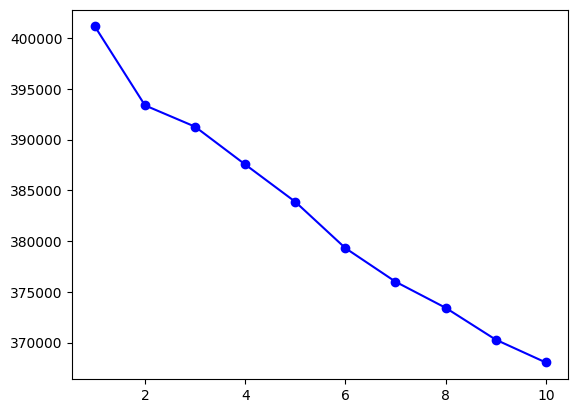

In [11]:
from sklearn.cluster import KMeans

list=range(1,11)
inertia=[]

for i in list:
    model=KMeans(n_clusters=i,random_state=42)
    model.fit(ti)
    inertia.append(model.inertia_)
plt.plot(list,inertia,c="blue",marker="o")
plt.show()

In [12]:
print("Best k point is likely 3 or 4")
print("I choose K===3")

Best k point is likely 3 or 4
I choose K===3


In [13]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3,random_state=42)
model.fit(ti)

KMeans(n_clusters=3, random_state=42)

In [14]:
print(model.inertia_)


391262.0022657651


In [15]:
print(model.labels_)


[1 1 1 ... 2 1 1]


In [16]:
print("clusters",model.cluster_centers_)

clusters [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.88754421e-03 1.28142610e-03 9.77109575e-03 ... 1.12217644e-05
  5.49864352e-03 1.35475185e-05]
 [1.40221457e-02 0.00000000e+00 8.13874129e-03 ... 2.89549576e-03
  0.00000000e+00 0.00000000e+00]]


In [17]:
dfff["clusters"]=model.labels_
dfff

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cleaned_Description,clusters
0,536365,85123A,6,12-01-10 08:26,2.55,17850.0,United Kingdom,white hanging heart tlight holder,1
1,536365,71053,6,12-01-10 08:26,3.39,17850.0,United Kingdom,white metal lantern,1
2,536365,84406B,8,12-01-10 08:26,2.75,17850.0,United Kingdom,cream cupid hearts coat hanger,1
3,536365,84029G,6,12-01-10 08:26,3.39,17850.0,United Kingdom,knitted union flag hot water bottle,1
4,536365,84029E,6,12-01-10 08:26,3.39,17850.0,United Kingdom,red woolly hottie white heart,1
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,12,12-09-11 12:50,0.85,12680.0,France,pack of 20 spaceboy napkins,1
541905,581587,22899,6,12-09-11 12:50,2.10,12680.0,France,childrens apron dolly girl,2
541906,581587,23254,4,12-09-11 12:50,4.15,12680.0,France,childrens cutlery dolly girl,2
541907,581587,23255,4,12-09-11 12:50,4.15,12680.0,France,childrens cutlery circus parade,1
